# Laptop Price Prediction

In [ ]:
#First we need to import our required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [234]:
df = pd.read_csv("laptop_data.csv")

In [235]:
df.head(10)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
5,5,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,21312.0000
6,6,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,114017.6016
7,7,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,61735.5360
8,8,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,79653.6000
9,9,Acer,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,41025.6000


**Price**

In [236]:
df['Price'].value_counts()

Price
58554.7200     14
79866.7200     14
95850.7200     14
26586.7200     11
63882.7200     11
               ..
26581.3920      1
130001.6016     1
18381.0672      1
20986.9920      1
41025.6000      1
Name: count, Length: 791, dtype: int64

/tmp/ipykernel_8438/834922981.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price'])


<Axes: xlabel='Price', ylabel='Density'>

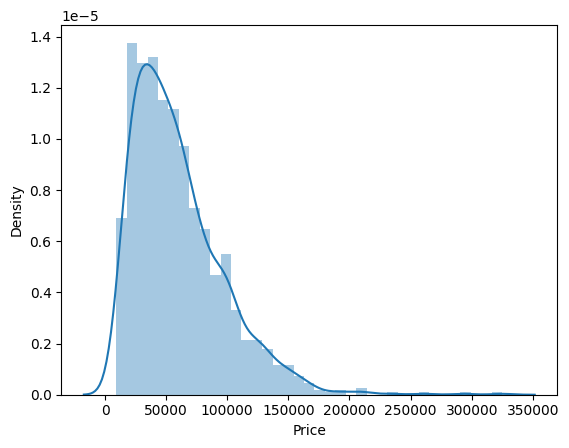

In [237]:
sns.distplot(df['Price'])

In [238]:
skew = df['Price'].skew()
print(f"Skewness of Price is : {skew}")

Skewness of Price is : 1.5208655681688517


**The Price is positively right skewed**

<Axes: xlabel='Price', ylabel='Count'>

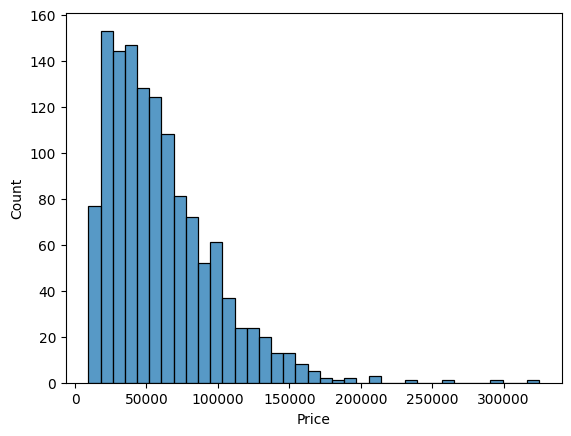

In [239]:
sns.histplot(df['Price'])

In [240]:
#First we removed unnamed column
df.drop(columns= ['Unnamed: 0'], inplace=True)

In [241]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [242]:
#Check the shape of dataset
df.shape

(1303, 11)

**Dataset Shape**:

1303 Rows and 11 Columns

In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   object 
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   object 
 10  Price             1303 non-null   float64
dtypes: float64(2), object(9)
memory usage: 112.1+ KB


In [244]:
#Check the missing values
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

# Univariate Analysis

**Company**

In [245]:
df['Company'].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
Fujitsu        3
Google         3
LG             3
Huawei         2
Name: count, dtype: int64

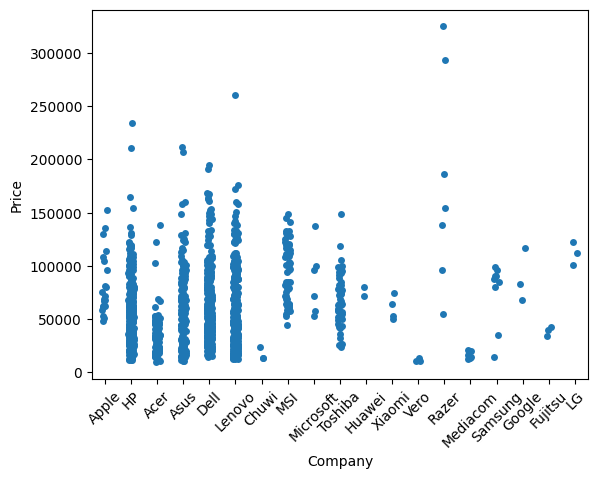

In [246]:
sns.stripplot(data=df, x='Company', y='Price', jitter=True)
plt.xticks(rotation=45)
plt.show()

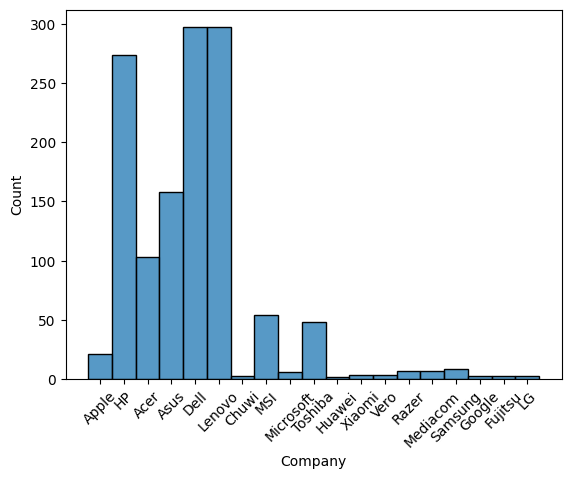

In [247]:
sns.histplot(data=df, x='Company')
plt.xticks(rotation=45) # Rotate by 45 or 90 degrees
plt.show()

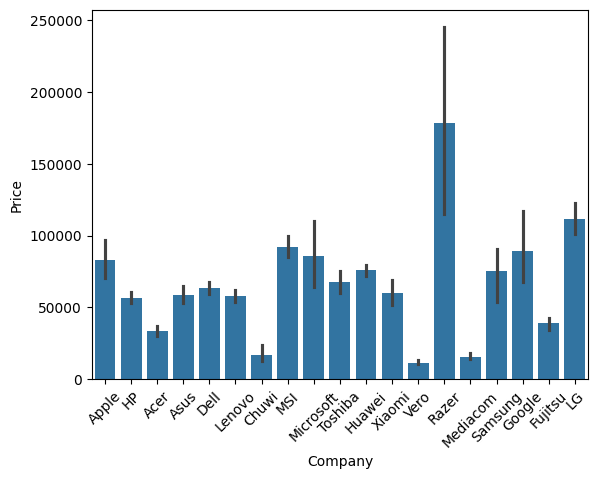

In [248]:
sns.barplot(data=df, x='Company', y='Price')
plt.xticks(rotation=45)
plt.show()

In [249]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


**TypeName**

In [250]:
vc = df['TypeName'].value_counts()
print(f"Total value counts of TypeName :")
print("="*40)
print(vc)

Total value counts of TypeName :
TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64


<Axes: xlabel='TypeName'>

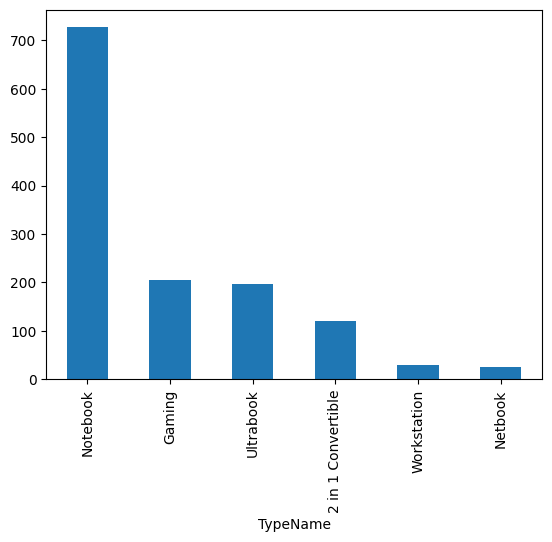

In [251]:
#put these value_count on barplot
df['TypeName'].value_counts().plot(kind='bar')

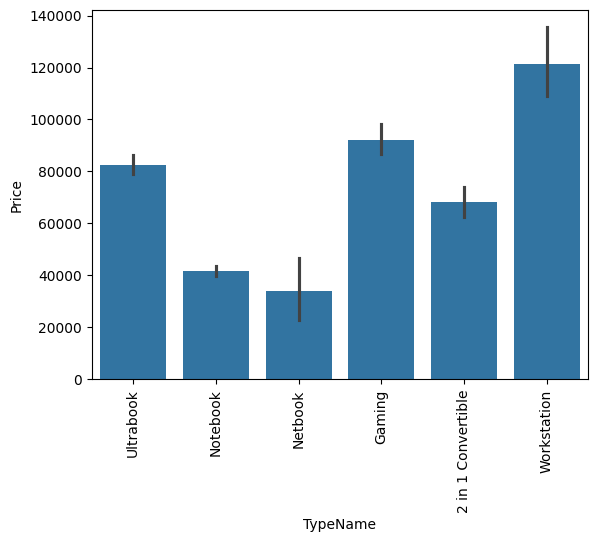

In [252]:
sns.barplot(x=df['TypeName'], y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

**Obervations**:

**Notebook:** Affordable prices

**Workstation, Ultrabook, Gaming:** High prices

In [253]:
df.head(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
5,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,21312.0000
6,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,114017.6016
7,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,61735.5360
8,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,79653.6000
9,Acer,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,41025.6000


**Inches**

In [254]:
df['Inches'].value_counts()

Inches
15.6    665
14.0    197
13.3    164
17.3    164
12.5     39
11.6     33
13.5      6
12.0      6
13.9      6
12.3      5
10.1      4
15.4      4
15.0      4
13.0      2
18.4      1
17.0      1
14.1      1
11.3      1
Name: count, dtype: int64

/tmp/ipykernel_8438/1439577752.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Inches'])


<Axes: xlabel='Inches', ylabel='Density'>

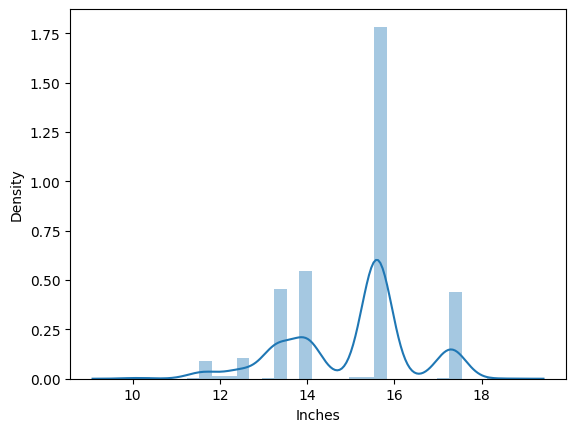

In [255]:
sns.distplot(df['Inches'])

<Axes: xlabel='Inches', ylabel='Price'>

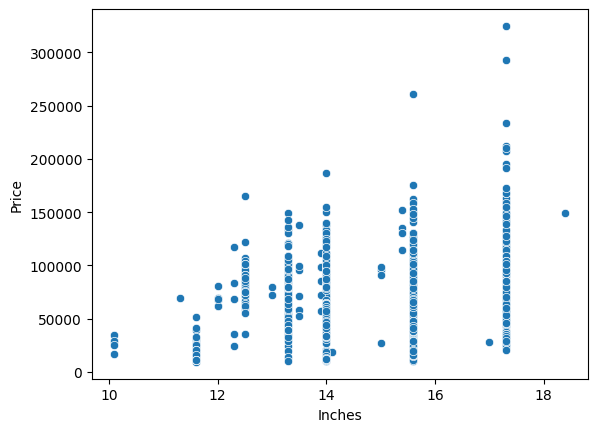

In [256]:
sns.scatterplot(x=df['Inches'], y = df['Price'])

In [257]:
df.head(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [258]:
df['Ram'] = df['Ram'].str.replace('GB', '')
df['Weight'] = df['Weight'].str.replace('kg', '')

In [259]:
df['Ram'] = df['Ram'].astype('int32')
df['Weight'] = df['Weight'].astype('float32')

In [260]:
df.head(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


In [261]:
df['Ram'].value_counts()

Ram
8     619
4     375
16    200
6      41
12     25
2      22
32     17
24      3
64      1
Name: count, dtype: int64

/tmp/ipykernel_8438/863594587.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Ram'])


<Axes: xlabel='Ram', ylabel='Density'>

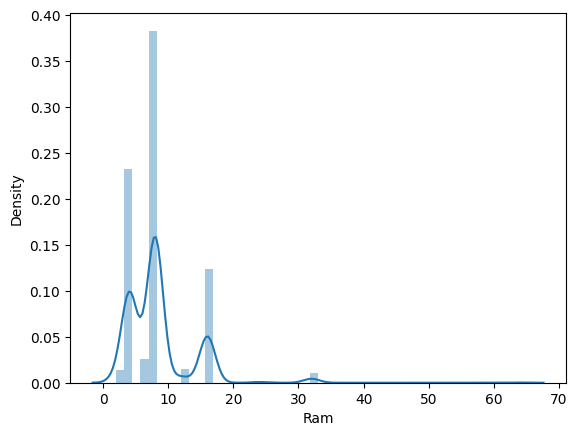

In [262]:
sns.distplot(df['Ram'])

<Axes: xlabel='Ram', ylabel='Price'>

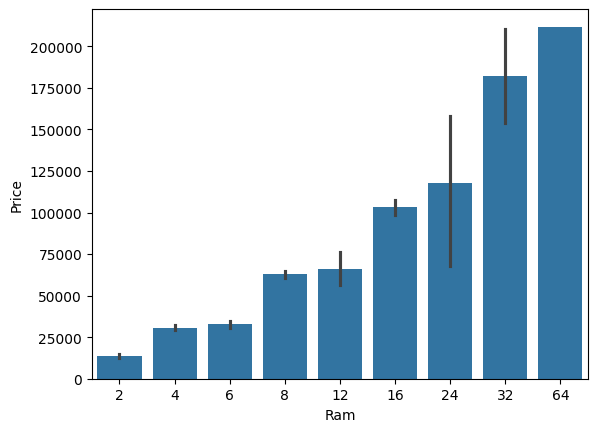

In [263]:
sns.barplot(x=df['Ram'], y=df['Price'])

In [264]:
df['Weight'].value_counts().sort_values(ascending=False)

Weight
2.200    126
2.100     58
2.000     45
2.400     44
2.300     41
        ... 
0.990      1
2.591      1
2.210      1
2.191      1
2.340      1
Name: count, Length: 171, dtype: int64

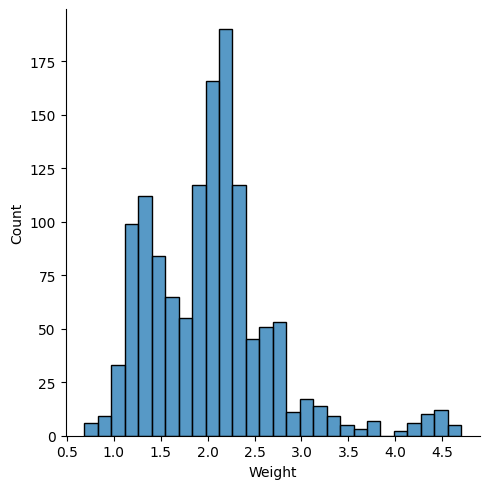

In [265]:
sns.displot(df['Weight'])

<Axes: xlabel='Weight', ylabel='Price'>

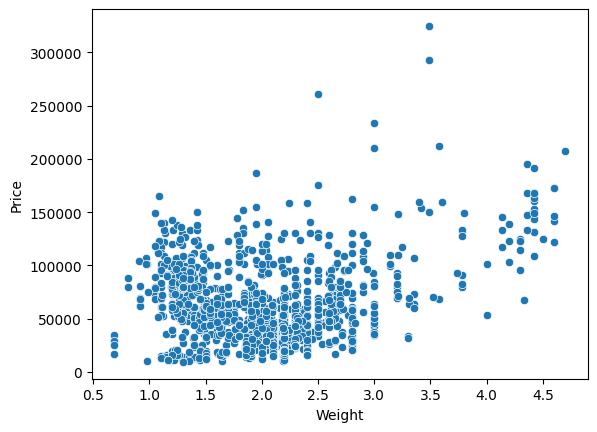

In [266]:
sns.scatterplot(x=df['Weight'], y=df['Price'])

In [267]:
data = df[df['Weight']>3.00]

<Axes: xlabel='Weight', ylabel='Price'>

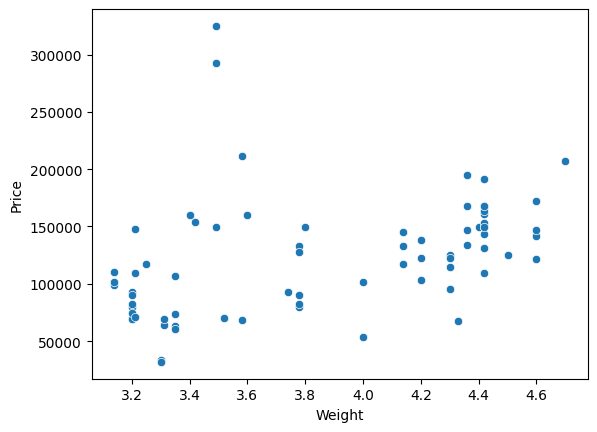

In [268]:
sns.scatterplot(x=data['Weight'], y= data['Price'])

**So as we see most of the laptop weight greate 3kg are gaming and workstation laptops**

In [269]:
correlation = df['Price'].corr(df['Weight'])
print(correlation)

0.21036980196834215


**The correlation b/w weight and price are not very good**

In [270]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


**ScreenResolution**

In [271]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [272]:
df['TouchScreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [273]:
df.sample(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen
111,Dell,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7560U 2.4GHz,8,256GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.23,73473.1200,1
49,Asus,Notebook,17.3,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4,1TB HDD,Nvidia GeForce 920MX,Windows 10,2.80,24828.4800,0
960,Toshiba,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6300U 2.4GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.20,81784.8000,0
681,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3350 1.1GHz,4,128GB SSD,Intel HD Graphics 500,Windows 10,1.86,22324.3200,0
782,Toshiba,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i7 6600U 2.6GHz,16,512GB SSD,Nvidia GeForce 930M,Windows 10,1.47,93985.9200,0
923,Toshiba,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6600U 2.6GHz,16,256GB SSD,Nvidia GeForce 930M,Windows 10,2.40,105228.0000,0
859,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4,1TB HDD,Intel HD Graphics 520,No OS,2.20,24988.3200,0
1119,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 960M,Windows 10,3.52,69929.4672,0
1196,Lenovo,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,4,1TB HDD,AMD Radeon R5 M430,No OS,1.90,19607.0400,0
196,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32,1TB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49,324954.7200,1


In [274]:
df['IPS'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [275]:
df.sample(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS
1151,HP,Notebook,15.6,1366x768,AMD E-Series 7110 1.8GHz,4,500GB HDD,AMD Radeon R2 Graphics,Windows 10,1.86,15824.1600,0,0
236,Acer,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,4,1TB HDD,Intel HD Graphics 520,Linux,2.10,20779.2000,0,0
420,Lenovo,2 in 1 Convertible,15.6,IPS Panel 4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7700HQ 2.8GHz,16,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.00,101178.7200,1,1
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1
1207,Lenovo,Notebook,15.6,1366x768,AMD E-Series 9000 2.2GHz,4,500GB HDD,AMD Radeon R2 Graphics,Windows 10,2.20,15930.7200,0,0
376,Lenovo,Netbook,11.6,IPS Panel 1366x768,Intel Celeron Quad Core N3450 1.1GHz,4,128GB SSD,Intel HD Graphics 500,Windows 10,1.59,29463.8400,0,1
42,Asus,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,8,1TB HDD,Nvidia GeForce 940MX,Linux,2.30,27864.9072,0,0
681,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3350 1.1GHz,4,128GB SSD,Intel HD Graphics 500,Windows 10,1.86,22324.3200,0,0
633,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4,1TB HDD,Nvidia GeForce 920MX,Windows 10,2.20,30849.1200,0,0
1084,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,2.18,39960.0000,0,0


In [276]:
new = df['ScreenResolution'].str.split('x',n=1, expand = True)

In [277]:
df['x_res'] = new[0]
df['y_res'] = new[1]


In [278]:
# Ye har row ke aakhri word (2560) ko nikal lega
df['x_res']=df['x_res'].str.split().str[-1]


In [279]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600


<Axes: xlabel='TouchScreen', ylabel='Price'>

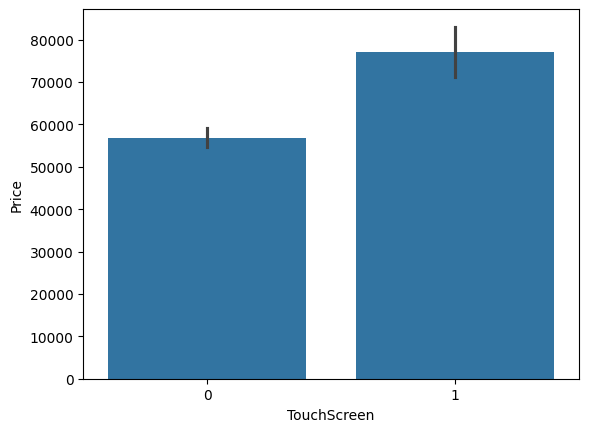

In [280]:
sns.barplot(x=df["TouchScreen"], y= df['Price'])

<Axes: xlabel='IPS', ylabel='Price'>

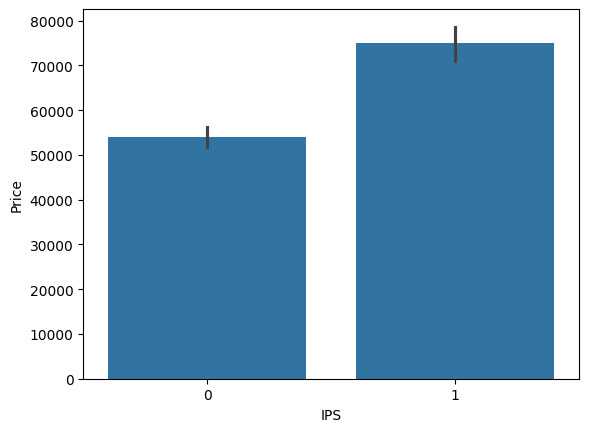

In [281]:
sns.barplot(x=df["IPS"], y= df['Price'])

In [282]:
df['x_res'] = df['x_res'].astype(int)
df['y_res'] = df['y_res'].astype(int)

In [283]:
ppi = ((df['x_res']**2)+(df['y_res']**2))**0.5/(df['Inches']).astype(float)
ppi

0       226.983005
1       127.677940
2       141.211998
3       220.534624
4       226.983005
           ...    
1298    157.350512
1299    276.053530
1300    111.935204
1301    100.454670
1302    100.454670
Length: 1303, dtype: float64

In [284]:
df.drop(columns=['ScreenResolution'],inplace=True)

In [285]:
df.drop(columns=['Inches','x_res','y_res'],inplace=True)

In [286]:
df.head(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1


In [287]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [288]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Others/No OS/Linux'

In [289]:


df['OpSys'] = df['OpSys'].apply(cat_os)

In [290]:
df['OpSys'].nunique()

3

<Axes: xlabel='OpSys', ylabel='Price'>

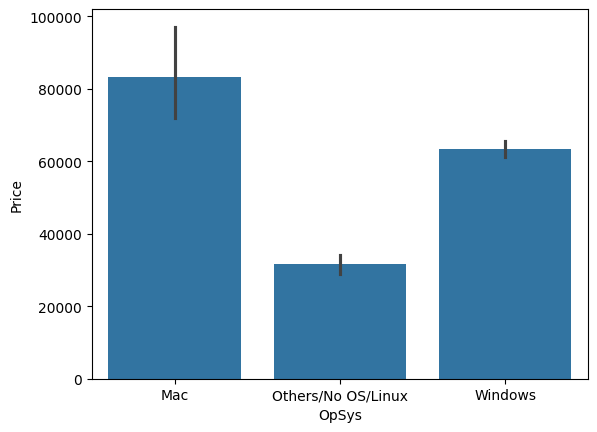

In [291]:
sns.barplot(x=df['OpSys'], y=df['Price'])

In [292]:
df.head(10)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,Mac,1.37,71378.6832,0,1
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,47895.5232,0,0
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Others/No OS/Linux,1.86,30636.0000,0,0
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,Mac,1.83,135195.3360,0,1
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,Mac,1.37,96095.8080,0,1
5,Acer,Notebook,AMD A9-Series 9420 3GHz,4,500GB HDD,AMD Radeon R5,Windows,2.10,21312.0000,0,0
6,Apple,Ultrabook,Intel Core i7 2.2GHz,16,256GB Flash Storage,Intel Iris Pro Graphics,Mac,2.04,114017.6016,0,1
7,Apple,Ultrabook,Intel Core i5 1.8GHz,8,256GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,61735.5360,0,0
8,Asus,Ultrabook,Intel Core i7 8550U 1.8GHz,16,512GB SSD,Nvidia GeForce MX150,Windows,1.30,79653.6000,0,0
9,Acer,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows,1.60,41025.6000,0,1


In [293]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

In [294]:
df['Cpu_name'] = df['Cpu'].apply(lambda x: " ".join(x.split()[0:3]))

In [295]:
def processor_find(text):
    if text =="Intel Core i7" or text == "Intel Core i5" or text == "Intel Core i3":
        return text
    else:
        if text.split()[0] == "Intel":
           return "Other Intel Processor"
        else:
            return "AMD Processor"

In [296]:
df['Cpu_brand'] = df['Cpu_name'].apply(processor_find)

In [297]:
df.sample(10)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,Cpu_name,Cpu_brand
725,Lenovo,Notebook,Intel Core i5 7200U 2.5GHz,4,1TB HDD,Intel HD Graphics 620,Others/No OS/Linux,1.90,26101.8720,0,0,Intel Core i5,Intel Core i5
534,Asus,Gaming,Intel Core i5 7300HQ 2.5GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows,2.30,87858.7200,0,1,Intel Core i5,Intel Core i5
1111,Dell,Notebook,Intel Core i5 6200U 2.3GHz,4,500GB HDD,AMD Radeon R5 M315,Windows,2.24,40980.3120,0,0,Intel Core i5,Intel Core i5
1076,Lenovo,Notebook,Intel Core i5 6300HQ 2.3GHz,4,1TB HDD,Nvidia GeForce GTX 950M,Windows,2.30,52054.5600,0,1,Intel Core i5,Intel Core i5
483,Chuwi,Notebook,Intel Atom x5-Z8350 1.44GHz,4,64GB Flash Storage,Intel HD Graphics,Windows,1.89,13261.3920,0,0,Intel Atom x5-Z8350,Other Intel Processor
286,Lenovo,Notebook,Intel Core i7 7500U 2.7GHz,8,256GB SSD,Intel HD Graphics 630,Windows,1.95,58448.1600,0,1,Intel Core i7,Intel Core i7
1295,Dell,Notebook,Intel Core i7 7500U 2.7GHz,8,1TB HDD,AMD Radeon R5 M430,Others/No OS/Linux,2.30,42943.1472,0,0,Intel Core i7,Intel Core i7
813,Dell,Notebook,Intel Core i7 7500U 2.7GHz,8,1TB HDD,Nvidia GeForce GT 940MX,Windows,1.98,51202.0800,0,0,Intel Core i7,Intel Core i7
994,Dell,2 in 1 Convertible,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows,1.68,47365.9200,1,0,Intel Core i5,Intel Core i5
676,Asus,Ultrabook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows,1.10,60472.8000,0,0,Intel Core i5,Intel Core i5


<Axes: xlabel='Cpu_brand', ylabel='count'>

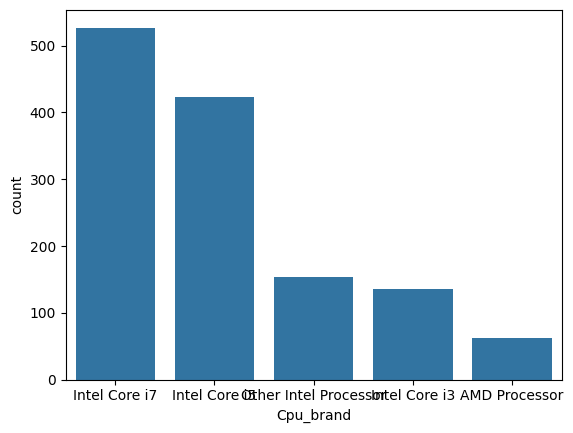

In [298]:
sns.barplot(df["Cpu_brand"].value_counts())

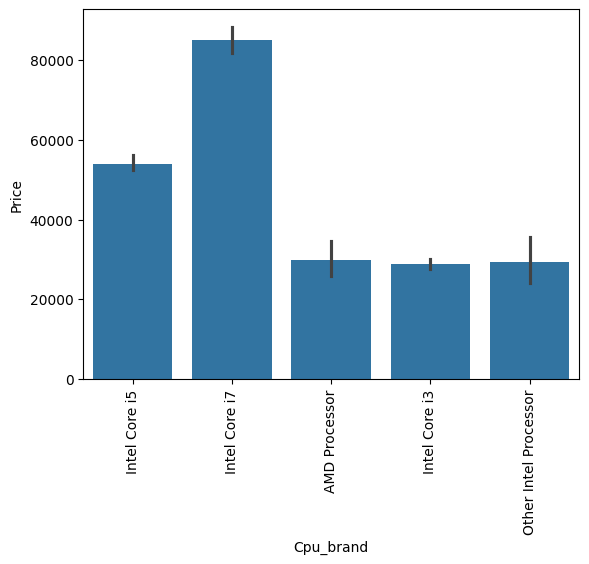

In [299]:
sns.barplot(x=df["Cpu_brand"], y = df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [300]:
df.drop(columns=['Cpu', 'Cpu_name'], inplace=True)

In [301]:
df.sample(15)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,Cpu_brand
258,MSI,Gaming,16,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows,4.14,133146.7200,0,0,Intel Core i7
939,Dell,Gaming,16,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1080,Windows,4.36,146946.2400,0,0,Intel Core i7
999,HP,Ultrabook,8,512GB SSD,Intel HD Graphics 620,Windows,1.48,111301.9200,0,0,Intel Core i7
696,Lenovo,2 in 1 Convertible,16,512GB SSD,Intel HD Graphics 620,Windows,1.38,93186.7200,1,0,Intel Core i7
254,Acer,Notebook,4,256GB SSD,Nvidia GeForce MX130,Windows,3.00,37402.5600,0,1,Intel Core i3
1027,HP,Notebook,4,500GB HDD,Intel HD Graphics 620,Windows,1.95,56476.8000,0,0,Intel Core i5
798,Lenovo,2 in 1 Convertible,8,256GB SSD,Intel HD Graphics 620,Windows,1.38,71874.7200,1,1,Intel Core i7
561,Lenovo,Notebook,4,128GB SSD,Intel HD Graphics 620,Windows,2.05,33566.4000,0,0,Intel Core i3
400,Lenovo,Notebook,4,1TB HDD,Intel HD Graphics 500,Windows,2.20,16303.6800,0,0,Other Intel Processor
895,Toshiba,Notebook,8,256GB SSD,Intel HD Graphics 620,Windows,1.05,78588.0000,0,0,Intel Core i5


In [302]:
df["Gpu_brand"] = df['Gpu'].apply(lambda x:x.split()[0])

In [303]:
df.head(10)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,Cpu_brand,Gpu_brand
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,Mac,1.37,71378.6832,0,1,Intel Core i5,Intel
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,47895.5232,0,0,Intel Core i5,Intel
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,Others/No OS/Linux,1.86,30636.0000,0,0,Intel Core i5,Intel
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,Mac,1.83,135195.3360,0,1,Intel Core i7,AMD
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,Mac,1.37,96095.8080,0,1,Intel Core i5,Intel
5,Acer,Notebook,4,500GB HDD,AMD Radeon R5,Windows,2.10,21312.0000,0,0,AMD Processor,AMD
6,Apple,Ultrabook,16,256GB Flash Storage,Intel Iris Pro Graphics,Mac,2.04,114017.6016,0,1,Intel Core i7,Intel
7,Apple,Ultrabook,8,256GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,61735.5360,0,0,Intel Core i5,Intel
8,Asus,Ultrabook,16,512GB SSD,Nvidia GeForce MX150,Windows,1.30,79653.6000,0,0,Intel Core i7,Nvidia
9,Acer,Ultrabook,8,256GB SSD,Intel UHD Graphics 620,Windows,1.60,41025.6000,0,1,Intel Core i5,Intel


In [304]:
df['Gpu_brand'].value_counts()

Gpu_brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [305]:
df = df[df["Gpu_brand"] != "ARM"]

In [306]:
df['Gpu_brand'].value_counts()

Gpu_brand
Intel     722
Nvidia    400
AMD       180
Name: count, dtype: int64

In [307]:
df.head(10)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,Cpu_brand,Gpu_brand
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,Mac,1.37,71378.6832,0,1,Intel Core i5,Intel
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,47895.5232,0,0,Intel Core i5,Intel
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,Others/No OS/Linux,1.86,30636.0000,0,0,Intel Core i5,Intel
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,Mac,1.83,135195.3360,0,1,Intel Core i7,AMD
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,Mac,1.37,96095.8080,0,1,Intel Core i5,Intel
5,Acer,Notebook,4,500GB HDD,AMD Radeon R5,Windows,2.10,21312.0000,0,0,AMD Processor,AMD
6,Apple,Ultrabook,16,256GB Flash Storage,Intel Iris Pro Graphics,Mac,2.04,114017.6016,0,1,Intel Core i7,Intel
7,Apple,Ultrabook,8,256GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,61735.5360,0,0,Intel Core i5,Intel
8,Asus,Ultrabook,16,512GB SSD,Nvidia GeForce MX150,Windows,1.30,79653.6000,0,0,Intel Core i7,Nvidia
9,Acer,Ultrabook,8,256GB SSD,Intel UHD Graphics 620,Windows,1.60,41025.6000,0,1,Intel Core i5,Intel


In [308]:
df.drop(columns=['Gpu'], inplace=True)

In [309]:
df.sample(15)

,Company,TypeName,Ram,Memory,OpSys,Weight,Price,TouchScreen,IPS,Cpu_brand,Gpu_brand
106,Lenovo,Notebook,4,1TB HDD,Windows,1.850,22105.872,0,0,Intel Core i3,Intel
875,Dell,Ultrabook,8,256GB SSD,Windows,1.600,90043.200,0,0,Intel Core i7,Intel
339,Dell,Notebook,8,256GB SSD,Windows,2.000,60885.720,0,0,Intel Core i5,Nvidia
1064,MSI,Gaming,16,256GB SSD + 1TB HDD,Windows,1.800,102777.120,0,0,Intel Core i7,Nvidia
825,Toshiba,Notebook,4,128GB SSD,Windows,1.750,26586.720,0,0,Other Intel Processor,Intel
70,Microsoft,Ultrabook,4,128GB SSD,Windows,1.252,58021.920,1,0,Intel Core i5,Intel
16,Dell,Notebook,8,256GB SSD,Windows,2.200,39693.600,0,0,Intel Core i7,AMD
688,HP,Notebook,6,2TB HDD,Windows,2.650,30316.320,0,1,AMD Processor,AMD
331,Toshiba,Notebook,8,256GB SSD,Windows,2.000,50243.040,0,1,Intel Core i5,Intel
1275,Asus,Ultrabook,8,512GB SSD,Windows,1.200,38841.120,0,1,Other Intel Processor,Intel


In [311]:
df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)
df['Memory'] = df['Memory'].str.replace('GB', '')
df['Memory'] = df['Memory'].str.replace('TB', '000')
new = df['Memory'].str.split("+", n=1, expand=True)
df['first'] = new[0]
df['first'] = df['first'].str.strip()
df['second'] = new[1]

df["layer1HDD"] = df['first'].apply(lambda x: 1 if "HDD" in x else 0)
df["layer1SSD"] = df['first'].apply(lambda x: 1 if "SSD" in x else 0)
df["layer1Hybrid"] = df['first'].apply(lambda x: 1 if "Hybrid" in x else 0)
df['layer1Flash_Storage'] = df['first'].apply(lambda x: 1 if "Flash Storage" in x else 0)
df['first'] = df['first'].str.replace(r'\D', '', regex=True)
df["second"].fillna("0", inplace = True)

df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['second'] = df['second'].str.replace(r'\D', '', regex=True)

df["first"] = df["first"].astype(int)
df["second"] = df["second"].astype(int)

/tmp/ipykernel_8438/2729550346.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["second"].fillna("0", inplace = True)


In [ ]:
df["HDD"]=(df["first"]*df["layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["layer1SSD"]+df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["layer1Hybrid"]+df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["layer1Flash_Storage"]+df["second"]*df["Layer2Flash_Storage"])


In [319]:
df.drop(columns=['first', 'second', 'layer1HDD', 'layer1SSD', 'layer1Hybrid',
       'layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [320]:
df.sample(10)

,Company,TypeName,Ram,Memory,OpSys,Weight,Price,TouchScreen,IPS,Cpu_brand,Gpu_brand,HDD,SSD,Hybrid,Flash_Storage
1026,HP,Notebook,4,500 HDD,Windows,2.31,63349.920,0,0,Intel Core i5,Intel,500,0,0,0
236,Acer,Notebook,4,1000 HDD,Others/No OS/Linux,2.10,20779.200,0,0,Intel Core i3,Intel,1000,0,0,0
939,Dell,Gaming,16,512 SSD + 1000 HDD,Windows,4.36,146946.240,0,0,Intel Core i7,Nvidia,1000,512,0,0
932,HP,Notebook,4,1000 HDD,Others/No OS/Linux,1.86,15392.592,0,0,Other Intel Processor,Intel,1000,0,0,0
944,Lenovo,2 in 1 Convertible,8,256 SSD,Windows,1.10,69210.720,1,1,Other Intel Processor,Intel,0,256,0,0
483,Chuwi,Notebook,4,64 Flash Storage,Windows,1.89,13261.392,0,0,Other Intel Processor,Intel,0,0,0,64
683,HP,Notebook,4,256 SSD,Windows,2.50,37242.720,0,1,Intel Core i3,AMD,0,256,0,0
689,Lenovo,Notebook,4,500 HDD,Windows,2.10,16943.040,0,0,Other Intel Processor,Intel,500,0,0,0
466,Acer,Notebook,4,500 HDD,Windows,2.20,24988.320,0,0,Intel Core i3,Nvidia,500,0,0,0
432,Lenovo,Notebook,4,128 SSD,Windows,1.70,31914.720,0,1,Intel Core i3,Intel,0,128,0,0


In [321]:
df.drop(columns=['Memory'], inplace=True)

In [322]:
df.head(10)

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,Cpu_brand,Gpu_brand,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,Mac,1.37,71378.6832,0,1,Intel Core i5,Intel,0,128,0,0
1,Apple,Ultrabook,8,Mac,1.34,47895.5232,0,0,Intel Core i5,Intel,0,0,0,128
2,HP,Notebook,8,Others/No OS/Linux,1.86,30636.0000,0,0,Intel Core i5,Intel,0,256,0,0
3,Apple,Ultrabook,16,Mac,1.83,135195.3360,0,1,Intel Core i7,AMD,0,512,0,0
4,Apple,Ultrabook,8,Mac,1.37,96095.8080,0,1,Intel Core i5,Intel,0,256,0,0
5,Acer,Notebook,4,Windows,2.10,21312.0000,0,0,AMD Processor,AMD,500,0,0,0
6,Apple,Ultrabook,16,Mac,2.04,114017.6016,0,1,Intel Core i7,Intel,0,0,0,256
7,Apple,Ultrabook,8,Mac,1.34,61735.5360,0,0,Intel Core i5,Intel,0,0,0,256
8,Asus,Ultrabook,16,Windows,1.30,79653.6000,0,0,Intel Core i7,Nvidia,0,512,0,0
9,Acer,Ultrabook,8,Windows,1.60,41025.6000,0,1,Intel Core i5,Intel,0,256,0,0


In [325]:
df.corr(numeric_only=True)['Price']

Ram              0.742905
Weight           0.209867
Price            1.000000
TouchScreen      0.192917
IPS              0.253320
HDD             -0.096891
SSD              0.670660
Hybrid           0.007942
Flash_Storage   -0.040067
Name: Price, dtype: float64

In [326]:
df.drop(columns=['Hybrid', "Flash_Storage"], inplace=True)

<Axes: >

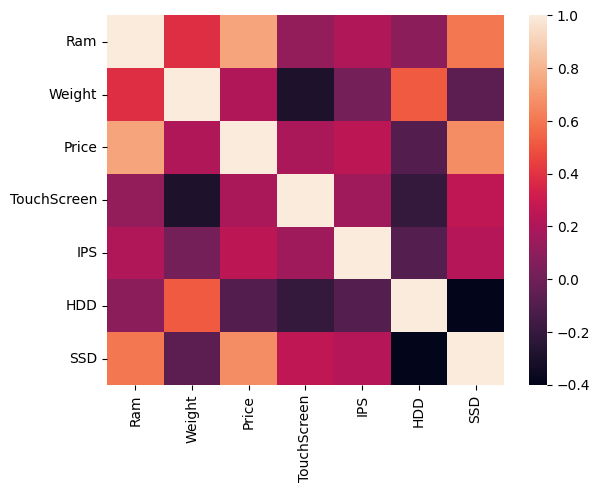

In [ ]:
sns.heatmap(df.corr(numeric_only=True))

/tmp/ipykernel_8438/3556049916.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df['Price']))


<Axes: xlabel='Price', ylabel='Density'>

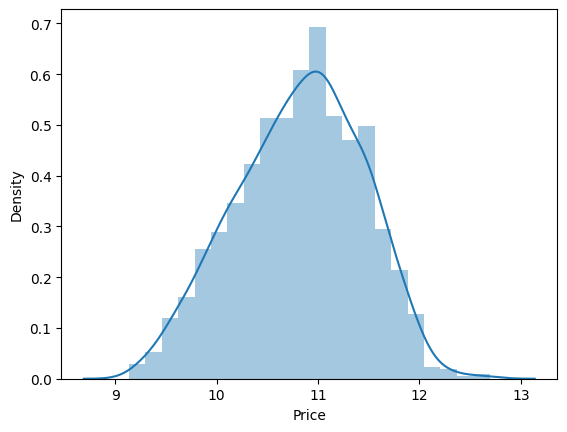

In [329]:
sns.distplot(np.log(df['Price']))

In [330]:
X = df.drop(columns=['Price'])
y = np.log(df['Price'])